# 🏭 Feature Engineering en Datos Industriales
Dataset: `unclean_sensor_data.csv`


### Nombres de Integrantes
* Karim Gracía Cortés
* Daniela Vargas Sánchez
  
## Contexto industrial de dataset
El motor monitoreado impulsa un sistema hidráhulico que regula flujo, presión, temperatura y eficiencia operativa dentro de una planta petroquímica. La planta ha enfrentado paradas no programadas y cosots elevados de matenimiento correctivo. Se propone implementar monitoreo predictivo para anticipar fallas del motor y reducir downtime.

Los datos provienen de:

1. Sensores térmicos (RTD o termopares)
2. Acelerómetros industriales
3. Sensores de presión hidráulica
4. Medidores de flujo


## Objetivo de la practica
Diseñar y justificar nuevas variables (features) a partir de sensores industriales, que sean útiles para el monitoreo predicitivo.

Enfoque: Fase **Data Preparation** de CRISP-DM.


`Agrega el código necesario en los apartados que se indican y documenta el código propuesto, especificando la función pricipal del mismo. Toma como base el dataset limpio que se trabajo la practica pasada`

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
 
sns.set_theme(style="whitegrid") # Estilo de los ejes de las tablas

pd.set_option("display.max_columns", None) # Muestra todas las columnas
pd.set_option("display.width", 140) # Configura el ancho en 140 caracteres

In [3]:
# Carga del dataset
df = pd.read_csv("datos_limpios.csv", sep=",", decimal=".")
df.head(10)

,Timestamp,Temperature (°C),Vibration (mm/s),Pressure (bar),Flow Rate (L/min),Efficiency (%)
0,2024-01-01 00:00:00,69.779570,0.896003,2.196334,447.485435,89.327750
1,2024-01-01 00:00:00,82.974601,3.110592,3.110580,222.490555,68.651984
2,2024-01-01 00:01:00,76.452902,6.376437,2.556589,363.421949,81.227055
3,2024-01-01 00:01:00,77.562998,1.057971,3.253704,206.671336,95.030315
4,2024-01-01 00:02:00,71.940435,0.434874,2.935875,447.829029,77.329880
5,2024-01-01 00:02:00,70.645506,0.905102,3.002867,312.517207,79.670811
6,2024-01-01 00:03:00,83.356770,0.587628,3.297378,391.160228,82.332951
7,2024-01-01 00:03:00,78.953362,1.064684,3.198188,144.353660,78.172967
8,2024-01-01 00:04:00,82.051562,3.344375,1.707913,397.435305,77.509114
9,2024-01-01 00:05:00,75.109908,8.537560,2.537794,438.185005,61.122444


# 🔹 Feature 1: Tasa de cambio
## Expresión matemática
ΔXₜ = Xₜ − Xₜ₋₁

## Justificación
Los cambios bruscos anticipan fallas más que valores absolutos.

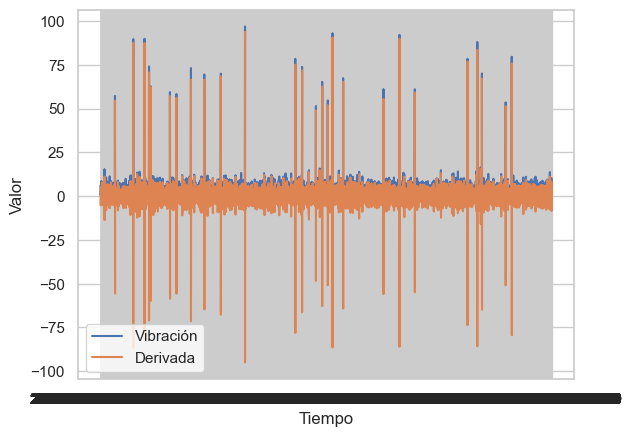

In [4]:
# Genera una nueva columna a partir de la derivada de la columna Vibration (mm/s), 
# apoyate de la función diff()
# Grafica la vibración respecto del tiempo así como la derivada y compara los resultados
df["Change Rate"] = df["Vibration (mm/s)"].diff()

plt.figure()

plt.plot(df["Timestamp"], df["Vibration (mm/s)"], label="Vibración")
plt.plot(df["Timestamp"], df["Change Rate"], label="Derivada")

plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿Los picos de vibración coinciden con picos en la primera derivada?
Sí, en muchos casos los picos de la señal de vibración coinciden con picos en la primera derivada. Esto ocurre porque cuando la vibración aumenta o disminuye rápidamente, la derivada muestra valores muy altos o muy bajos, indicando un cambio brusco en la señal.

2. ¿Existen cambios bruscos que no son evidentes en la señal original?
Sí. La derivada permite observar variaciones rápidas que en la señal original pueden parecer pequeñas o difíciles de notar. Aunque la vibración se vea relativamente estable, la derivada muestra picos pronunciados que indican cambios repentinos entre mediciones consecutivas.

3. ¿Los cambios extremos son aislados o recurrentes?
En la gráfica se observa que los cambios extremos aparecen varias veces a lo largo del tiempo, por lo que no parecen ser eventos completamente aislados. Esto sugiere que el sistema experimenta fluctuaciones recurrentes en la vibración.


4. ¿Podría esta variable anticipar una falla antes de que la vibración alcance niveles críticos?
Sí, potencialmente. La derivada mide la tasa de cambio de la vibración, por lo que puede detectar incrementos rápidos antes de que el valor de vibración llegue a niveles críticos. Esto puede servir como una señal temprana de posibles problemas en el sistema.

5. ¿Es más informativo el nivel de vibración o su tasa de cambio?
Ambos aportan información importante. El nivel de vibración indica el estado actual del sistema, mientras que la tasa de cambio (derivada) permite identificar cambios repentinos o tendencias que podrían anticipar fallas. Por lo tanto, analizar ambas variables conjuntamente proporciona un diagnóstico más completo.

# 🔹 Feature 2: Media móvil
## Expresión
μₜ = (1/n) Σ Xᵢ

## Justificación
Permite detectar tendencias reales eliminando ruido.

In [5]:
window = 60
df["Temperature (Roll Mean)"] = df["Temperature (°C)"].rolling(window).mean()
df[["Temperature (°C)", "Temperature (Roll Mean)"]].head(70)


,Temperature (°C),Temperature (Roll Mean)
0,69.779570,NaN
1,82.974601,NaN
2,76.452902,NaN
3,77.562998,NaN
4,71.940435,NaN
...,...,...
65,62.448889,75.668519
66,71.606479,75.472680
67,85.431321,75.580646
68,77.101549,75.498146


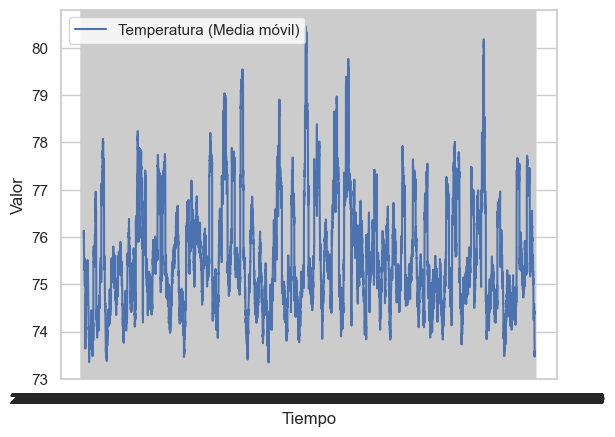

In [6]:
# Grafica la temperatura y la media móvil respecto del tiempo y compara
plt.figure()
 
plt.plot(df["Timestamp"], df["Temperature (Roll Mean)"], label="Temperatura (Media móvil)")

 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

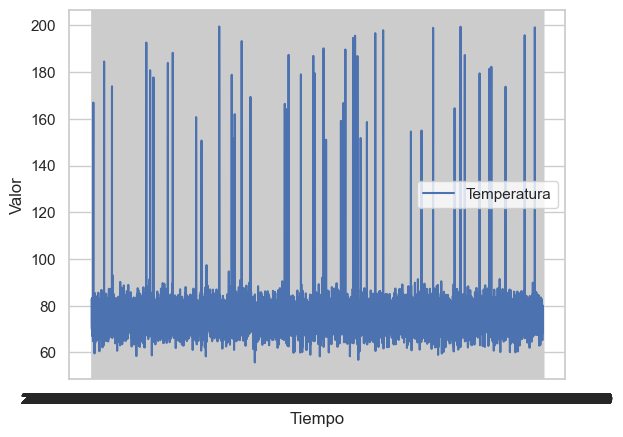

In [7]:
plt.figure()
 

plt.plot(df["Timestamp"], df["Temperature (°C)"], label="Temperatura")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

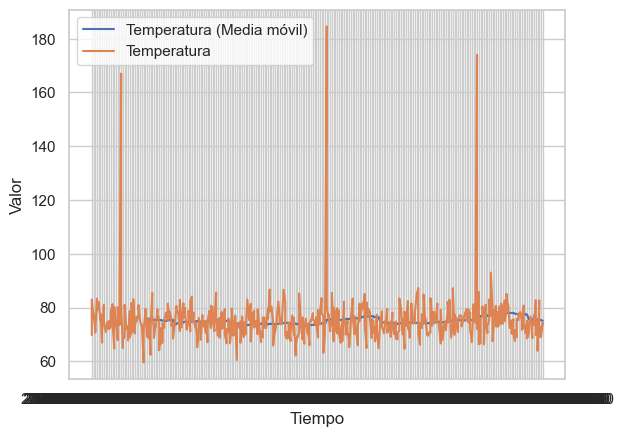

In [8]:
plt.figure()
 
plt.plot(df["Timestamp"].head(500), df["Temperature (Roll Mean)"].head(500), label="Temperatura (Media móvil)")
plt.plot(df["Timestamp"].head(500), df["Temperature (°C)"].head(500), label="Temperatura")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿La media móvil revela tendencias que no se observan claramente en la señal original?
Sí. La media móvil suaviza las fluctuaciones rápidas de la temperatura y permite observar con mayor claridad la tendencia general del comportamiento de la señal a lo largo del tiempo.

2. ¿La ventana de 60 muestras es adecuada o demasiado grande/pequeña?
La ventana de 60 muestras parece adecuada porque reduce el ruido de la señal y permite ver el comportamiento general. Sin embargo, puede ocultar algunos cambios bruscos o picos extremos presentes en la señal original.

3. ¿Cómo cambiaría la interpretación si modificamos el tamaño de ventana?
Si se usa una ventana más pequeña, la media móvil seguirá más de cerca la señal original y mostrará más variaciones. Si se usa una ventana más grande, la señal se suavizará más y mostrará principalmente la tendencia general, pero podría ocultar eventos importantes.

# 🔹 Feature 3: Desviación estándar móvil
## Expresión
σₜ = sqrt((1/n) Σ (Xᵢ − μ)²)

## Justificación
Detecta inestabilidad creciente previa a fallas.

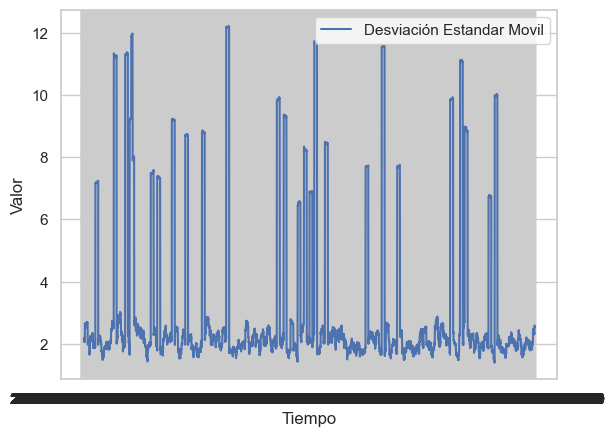

In [9]:
#Apoyate del código anterior, usa la misma ventana y genera una nueva característica con ventana móvil
#para la desviación estándar de las vibracionesy graficalo.
df["rollingstandarddeviation"] = df["Vibration (mm/s)"].rolling(window=60).std(ddof=0)

plt.figure()


plt.plot(df["Timestamp"], df["rollingstandarddeviation"], label="Desviación Estandar Movil")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿Existen periodos de alta volatilidad?
Sí. En la gráfica se observan varios picos altos en la desviación estándar móvil, lo que indica periodos donde la vibración varía mucho dentro de la ventana analizada. Estos picos representan momentos de mayor volatilidad en la señal.

2. ¿La inestabilidad es progresiva o repentina?
La inestabilidad parece ser repentina. Los picos aparecen de forma brusca y luego la señal vuelve rápidamente a valores bajos, lo que sugiere cambios rápidos en la variabilidad de la vibración.

3. ¿Se observan ciclos de estabilidad/inestabilidad?
Sí. Durante gran parte del tiempo la desviación estándar se mantiene en valores relativamente bajos (estabilidad), pero en ciertos momentos aparecen picos altos que indican periodos breves de inestabilidad.

4. ¿Podría la volatilidad ser mejor indicador de desgaste que la vibración absoluta?
En algunos casos sí. La volatilidad mide cuánto cambia la vibración en un periodo de tiempo, por lo que puede detectar comportamientos irregulares antes de que la vibración alcance valores altos. Esto puede ayudar a identificar posibles problemas o desgaste en el sistema de manera más temprana.

# 🔹 Feature 4: Interacción física (Presión × Flujo)
## Expresión
Carga ≈ Presión × Flujo

## Justificación
Aproxima carga operativa del sistema.

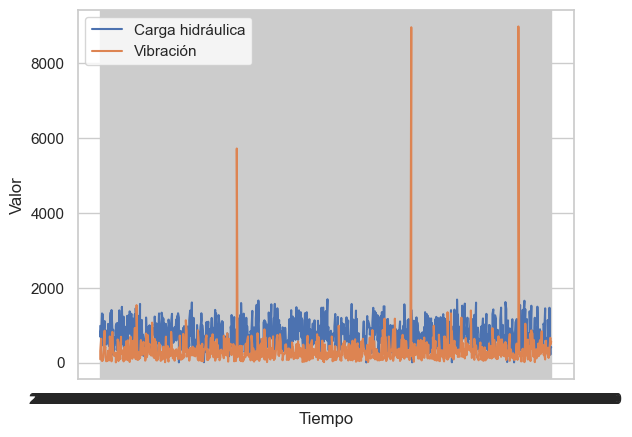

In [10]:
# Se calcula la carga hidráulica como el producto de la presión por el caudal.
# Esta operación funciona como una aproximación de la potencia hidráulica
# (relación física básica: Potencia ≈ Presión × Flujo).
df["Load"] = df["Pressure (bar)"] * df["Flow Rate (L/min)"]

# Se muestran las primeras 5 filas para verificar que la nueva columna
# se haya generado correctamente.
df.head(5)

# Se crea una nueva figura para la gráfica.
plt.figure()

# Se grafican las primeras 1000 muestras de la carga hidráulica
# para visualizar su comportamiento en el tiempo.
plt.plot(df["Timestamp"].head(1000),
         df["Load"].head(1000),
         label="Carga hidráulica")

# Se grafican las primeras 1000 muestras de vibración.
# La vibración se multiplica por 100 para escalarla y facilitar
# la comparación visual en la misma gráfica, ya que ambas variables
# tienen magnitudes muy distintas.
plt.plot(df["Timestamp"].head(1000),
         df["Vibration (mm/s)"].head(1000) * 100,
         label="Vibración")

# Etiquetas de los ejes.
plt.xlabel("Tiempo")
plt.ylabel("Valor")

# Se muestra la leyenda para identificar cada señal.
plt.legend()

# Se despliega la gráfica.
plt.show()

#### 1. ¿Qué puede generar una carga elevada?
Una carga elevada en un sistema hidráulico puede producirse por aumentos en la presión, restricciones en el flujo, mayor demanda del proceso o desgaste interno que obliga al motor a trabajar más. Físicamente, la carga está relacionada con la presión y el caudal, ya que la potencia hidráulica depende del producto de ambas variables.

#### 3. ¿La carga podría explicar cambios en vibración?
La carga puede explicar cambios en la vibración porque al aumentar el esfuerzo mecánico también aumentan las fuerzas dinámicas sobre el eje y los rodamientos. En condiciones normales la vibración crece ligeramente con la carga, pero si el aumento es desproporcionado puede indicar una falla mecánica.

#### 4. ¿Con qué otras variables en el dataset podemos relacionar la carga hifrahulica?
En el dataset, la carga puede relacionarse principalmente con la presión y el flujo, y también con la temperatura, la eficiencia y la vibración, ya que todas reflejan el nivel de esfuerzo y desempeño del sistema.

# 🔹 Feature 5: Health Index
## Expresión
HI = 0.3T + 0.4V + 0.3(100 − E)

## Justificación
Resume múltiples sensores en una métrica única para monitoreo.

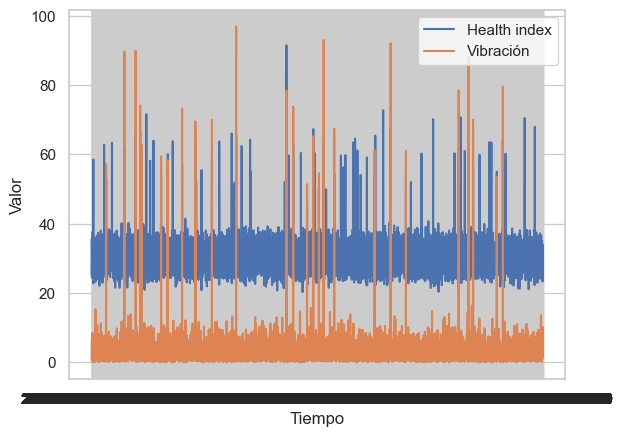

In [11]:
# Se calcula un índice de salud (health_index) como combinación ponderada
# de variables críticas del sistema.
# - 30% temperatura: refleja esfuerzo térmico.
# - 40% vibración: mayor peso por ser fuerte indicador de falla mecánica.
# - 30% pérdida de eficiencia: se usa (100 - eficiencia) para que
#   valores altos representen peor desempeño.
df["health_index"] = (
    0.3 * df["Temperature (°C)"] +
    0.4 * df["Vibration (mm/s)"] +
    0.3 * (100 - df["Efficiency (%)"])
)

# Se muestran las primeras filas del índice para verificar su cálculo.
df[["health_index"]].head()

# Se crea una nueva figura para graficar.
plt.figure()

# Se grafica el índice de salud a lo largo del tiempo.
# Este índice resume el estado general del motor.
plt.plot(df["Timestamp"], df["health_index"], label="Health index")

# Se grafica también la vibración para comparar visualmente
# cómo influye en el comportamiento del índice.
plt.plot(df["Timestamp"], df["Vibration (mm/s)"], label="Vibración")

# Etiquetas de los ejes.
plt.xlabel("Tiempo")
plt.ylabel("Valor")

# Se muestra la leyenda.
plt.legend()

# Se despliega la gráfica.
plt.show()

#### 1. ¿Qué significan los valores constantes y cómo estos afectan los resultados?
Los valores 0.3, 0.4 y 0.3 son ponderaciones que indican qué tanta influencia tiene cada variable en el health_index. Como la vibración tiene el mayor peso (0.4), afecta más el resultado final que la temperatura o la pérdida de eficiencia. Esto hace que el índice sea más sensible a cambios en vibración.

#### 3. ¿Cómo cambiaría el comportamiento si aumentamos el peso de vibración?
Si aumentamos el peso de la vibración, el índice reaccionará más fuertemente ante pequeñas variaciones en esa señal y su comportamiento se parecerá más al de la gráfica de vibración. Esto incrementa la sensibilidad a fallas mecánicas, pero reduce la influencia de las otras variables.


# Actividad Final

#### Anomalía térmica

Thermal_Anomaly = Temperature − Temperature (Roll Mean)

Esta variable mide cuánto se desvía la temperatura actual respecto a su comportamiento promedio reciente.

#### Justificación técnica

En sistemas hidráulicos de plantas petroquímicas:

- El aumento sostenido de temperatura suele preceder fallas por fricción, cavitación o problemas de enfriamiento.
- Comparar contra un promedio móvil elimina el efecto de tendencia normal operativa.
- Permite detectar eventos anómalos incluso si la temperatura absoluta aún está dentro de límites aceptables.

Esta feature es útil para modelos de mantenimiento predictivo porque captura desviaciones dinámicas, no solo valores absolutos.

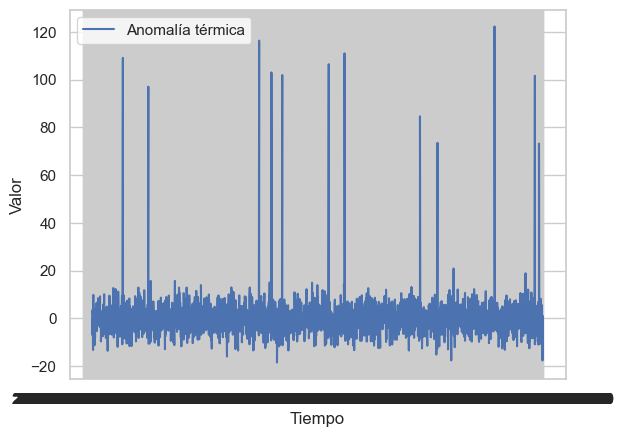

In [12]:
# Se calcula la anomalía térmica como la diferencia entre la temperatura
# actual y su promedio móvil. Esto permite identificar desviaciones
# respecto al comportamiento térmico esperado.
df["Thermal_Anomaly"] = df["Temperature (°C)"] - df["Temperature (Roll Mean)"]

# Se crea una nueva figura para la gráfica.
plt.figure()

# Se grafican las primeras 3000 muestras de la anomalía térmica
# para observar posibles sobrecalentamientos o caídas anormales
# en el comportamiento del sistema.
plt.plot(df["Timestamp"].head(3000),
         df["Thermal_Anomaly"].head(3000),
         label="Anomalía térmica")

# Etiquetas de los ejes.
plt.xlabel("Tiempo")
plt.ylabel("Valor")

# Se muestra la leyenda.
plt.legend()

# Se despliega la gráfica.
plt.show()